# Кластеризация ЕГЭ (4 если сделаны все задачи)

Рядом лежат данные с координатами точек. Везде используется Евклидово расстояние. Кластером считается набор не менее чем из 30 точек связанных друг с другом. Аномалия это точка находящаяся на расстоянии более 1 от любого кластера.

* Постройте Распределение точек
* Напишите руками DBSCAN и обработайте им все файлы
* Файл 0.xls также решите руками
* Постройте Распределение точек, отметьте принадлежность кластеров цветами
* Отметьте Аномалии отдельным цветом
* Найдите среди в каждом кластере точку расстояние от которой до всех остальных минимально
* Выведите два числа - Среднее абсцисс и ординат центроидов кластеров * 100000

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


Загружено 100 точек из файла 0.xls
          X         Y
0 -1.431692  0.905442
1  2.287223 -2.314738
2  2.116143 -1.878515
3 -1.030567  1.082829
4 -1.048093  0.843881


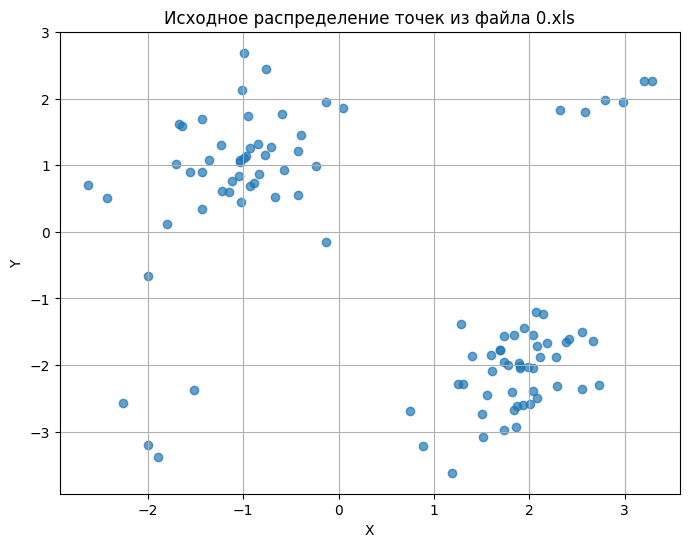

Найдено 2 кластеров
Найдено 10 аномалий
Кластер 1 - Центроидная точка: (-1.030567, 1.082829)
Кластер 2 - Центроидная точка: (1.905466, -2.040852)
Среднее абсцисс центроидов * 100000: 43744.972073
Среднее ординат центроидов * 100000: -47901.122310


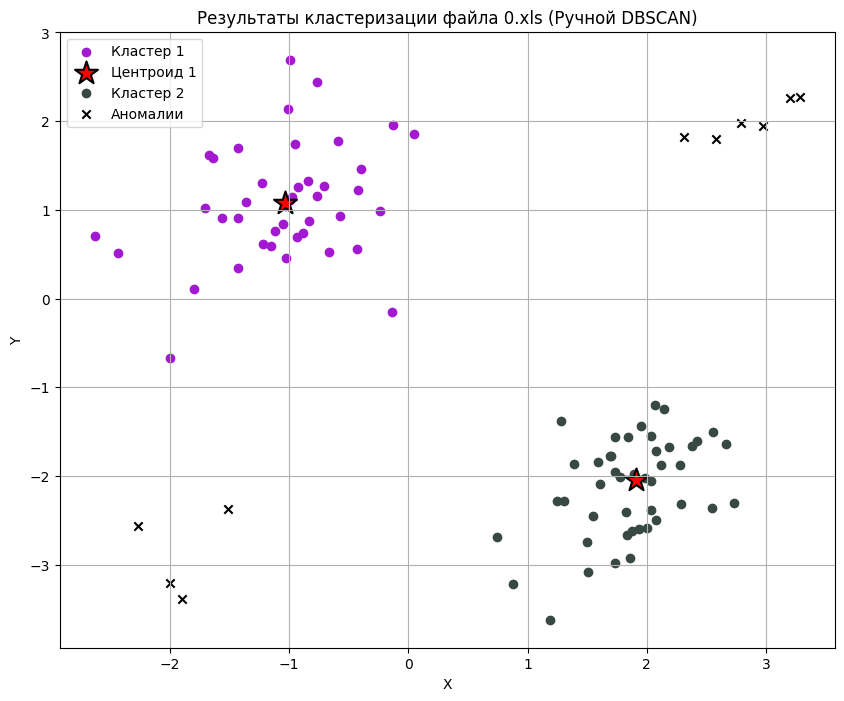

In [3]:
import matplotlib.pyplot as plt
from math import sqrt
import random

# Загрузка данных из Excel файла 0.xls
df = pd.read_excel('0.xls')
print(f"Загружено {len(df)} точек из файла 0.xls")
print(df.head())

# Преобразуем данные в список точек для обработки
a = df.values.tolist()

# Визуализация исходных данных
plt.figure(figsize=(8, 6))
plt.scatter(df['X'], df['Y'], alpha=0.7)
plt.title('Исходное распределение точек из файла 0.xls')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()

# Реализация алгоритма DBSCAN для кластеризации
cl = []  # Список кластеров
anom = []  # Список аномалий
a_copy = a.copy()  # Создаем копию массива, чтобы не изменять исходные данные

# Обрабатываем каждую точку
for i in range(len(a_copy)):
    if a_copy[i] != '*':  # Проверяем, не обработана ли уже точка
        b = []  # Текущий кластер/группа точек
        b.append(a_copy[i])
        a_copy[i] = '*'  # Помечаем точку как обработанную
        
        # Расширяем кластер, добавляя соседние точки
        for l in b:
            x, y = l
            for j in range(len(a_copy)):
                if a_copy[j] != '*':  # Проверяем только необработанные точки
                    # Вычисляем евклидово расстояние между точками
                    if ((x - a_copy[j][0])**2 + (y - a_copy[j][1])**2)**0.5 <= 1:
                        b.append(a_copy[j])
                        a_copy[j] = '*'  # Помечаем точку как обработанную
        
        # Определяем, является ли группа точек кластером или аномалиями
        if len(b) >= 30:  # Порог для определения кластера
            cl.append(b)
        else:
            for k in range(len(b)):
                anom.append(b[k])

print(f"Найдено {len(cl)} кластеров")
print(f"Найдено {len(anom)} аномалий")

# Для каждого кластера найдем точку с минимальным суммарным расстоянием
# до всех остальных точек кластера (центроид)
sm_x = sm_y = 0
centroids = []

for k in range(len(cl)):
    s_x = s_y = 0
    mn = float('inf')  # Используем float('inf') вместо большого числа
    
    for j in cl[k]:
        x, y = j
        d = 0  # Суммарное расстояние до всех точек в кластере
        
        for i in cl[k]:
            d += ((x - i[0])**2 + (y - i[1])**2)**0.5
            
        if d < mn:
            mn = d
            s_x, s_y = x, y
    
    # Добавляем координаты центроида в общую сумму
    sm_x += s_x
    sm_y += s_y
    centroids.append([s_x, s_y])
    print(f"Кластер {k+1} - Центроидная точка: ({s_x:.6f}, {s_y:.6f})")

# Вычисляем и выводим средние значения координат центроидов * 100000
avg_x = sm_x / len(cl) if cl else 0
avg_y = sm_y / len(cl) if cl else 0
print(f"Среднее абсцисс центроидов * 100000: {avg_x * 100000:.6f}")
print(f"Среднее ординат центроидов * 100000: {avg_y * 100000:.6f}")

# Генерируем случайные цвета для кластеров
colors = []
for _ in range(len(cl)):
    color = f'#{random.randint(0, 0xFFFFFF):06x}'
    while color == '#000000':  # Избегаем черного цвета для кластеров
        color = f'#{random.randint(0, 0xFFFFFF):06x}'
    colors.append(color)

# Визуализация результатов кластеризации
plt.figure(figsize=(10, 8))

# Отображаем каждый кластер своим цветом
for i, cluster in enumerate(cl):
    x, y = zip(*cluster)
    plt.scatter(x, y, color=colors[i], label=f'Кластер {i+1}')
    
    # Выделяем центроидную точку для кластера
    plt.scatter(centroids[i][0], centroids[i][1], color='red', marker='*', s=300, 
                edgecolor='black', linewidth=1.5, label=f'Центроид {i+1}' if i == 0 else "")

# Отображаем аномалии черным цветом
if anom:
    x_anom, y_anom = zip(*anom)
    plt.scatter(x_anom, y_anom, color='black', marker='x', label='Аномалии')

plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Результаты кластеризации файла 0.xls (Ручной DBSCAN)')
plt.grid(True)

plt.show()


Загружено 9999 точек из файла 1.xls
          X         Y
0  1.927496 -2.247686
1  1.987569  3.899476
2  2.344332  4.039117
3 -1.011184  0.997512
4  2.184801 -1.380419


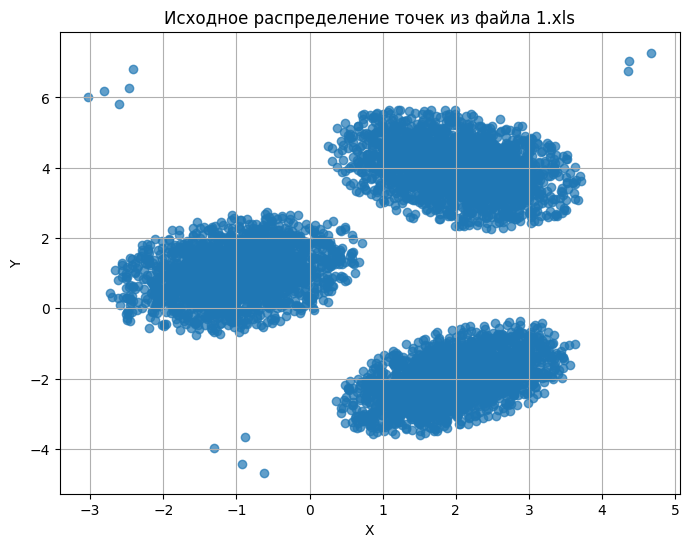

Найдено 3 кластеров
Найдено 12 аномалий
Кластер 1 - Центроидная точка: (1.997911, -1.999164)
Кластер 1 - Центроидная точка: (1.997911, -1.999164)
Кластер 2 - Центроидная точка: (2.001615, 3.998195)
Кластер 2 - Центроидная точка: (2.001615, 3.998195)
Кластер 3 - Центроидная точка: (-1.002671, 1.003715)
Среднее абсцисс центроидов * 100000: 99895.161267
Среднее ординат центроидов * 100000: 100091.521724
Кластер 3 - Центроидная точка: (-1.002671, 1.003715)
Среднее абсцисс центроидов * 100000: 99895.161267
Среднее ординат центроидов * 100000: 100091.521724


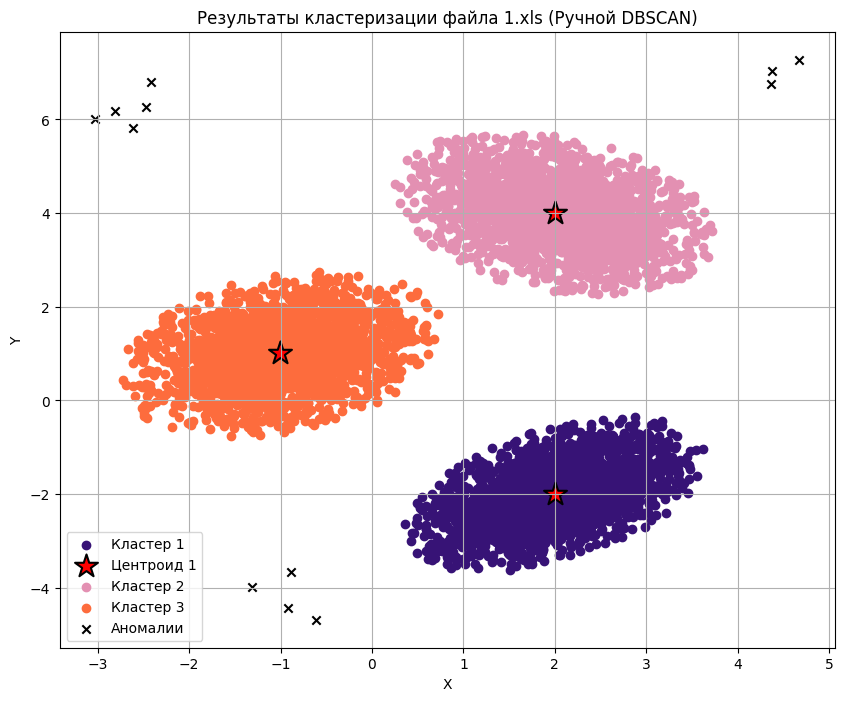

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from math import sqrt
import random

# Загрузка данных из Excel файла 1.xls
df = pd.read_excel('1.xls')
print(f"Загружено {len(df)} точек из файла 1.xls")
print(df.head())

# Преобразуем данные в список точек для обработки
a = df.values.tolist()

# Визуализация исходных данных
plt.figure(figsize=(8, 6))
plt.scatter(df['X'], df['Y'], alpha=0.7)
plt.title('Исходное распределение точек из файла 1.xls')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()

# Реализация алгоритма DBSCAN для кластеризации
cl = []  # Список кластеров
anom = []  # Список аномалий
a_copy = a.copy()  # Создаем копию массива, чтобы не изменять исходные данные

# Обрабатываем каждую точку
for i in range(len(a_copy)):
    if a_copy[i] != '*':  # Проверяем, не обработана ли уже точка
        b = []  # Текущий кластер/группа точек
        b.append(a_copy[i])
        a_copy[i] = '*'  # Помечаем точку как обработанную
        
        # Расширяем кластер, добавляя соседние точки
        for l in b:
            x, y = l
            for j in range(len(a_copy)):
                if a_copy[j] != '*':  # Проверяем только необработанные точки
                    # Вычисляем евклидово расстояние между точками
                    # Для файла 1 используем порог 0.5 как было в оригинальном коде
                    if ((x - a_copy[j][0])**2 + (y - a_copy[j][1])**2)**0.5 <= 0.5:
                        b.append(a_copy[j])
                        a_copy[j] = '*'  # Помечаем точку как обработанную
        
        # Определяем, является ли группа точек кластером или аномалиями
        if len(b) >= 30:  # Порог для определения кластера
            cl.append(b)
        else:
            for k in range(len(b)):
                anom.append(b[k])

print(f"Найдено {len(cl)} кластеров")
print(f"Найдено {len(anom)} аномалий")

# Для каждого кластера найдем точку с минимальным суммарным расстоянием
# до всех остальных точек кластера (центроид)
sm_x = sm_y = 0
centroids = []

for k in range(len(cl)):
    s_x = s_y = 0
    mn = float('inf')  # Используем float('inf') вместо большого числа
    
    for j in cl[k]:
        x, y = j
        d = 0  # Суммарное расстояние до всех точек в кластере
        
        for i in cl[k]:
            d += ((x - i[0])**2 + (y - i[1])**2)**0.5
            
        if d < mn:
            mn = d
            s_x, s_y = x, y
    
    # Добавляем координаты центроида в общую сумму
    sm_x += s_x
    sm_y += s_y
    centroids.append([s_x, s_y])
    print(f"Кластер {k+1} - Центроидная точка: ({s_x:.6f}, {s_y:.6f})")

# Вычисляем и выводим средние значения координат центроидов * 100000
avg_x = sm_x / len(cl) if cl else 0
avg_y = sm_y / len(cl) if cl else 0
print(f"Среднее абсцисс центроидов * 100000: {avg_x * 100000:.6f}")
print(f"Среднее ординат центроидов * 100000: {avg_y * 100000:.6f}")

# Генерируем случайные цвета для кластеров
colors = []
for _ in range(len(cl)):
    color = f'#{random.randint(0, 0xFFFFFF):06x}'
    while color == '#000000':  # Избегаем черного цвета для кластеров
        color = f'#{random.randint(0, 0xFFFFFF):06x}'
    colors.append(color)

# Визуализация результатов кластеризации
plt.figure(figsize=(10, 8))

# Отображаем каждый кластер своим цветом
for i, cluster in enumerate(cl):
    x, y = zip(*cluster)
    plt.scatter(x, y, color=colors[i], label=f'Кластер {i+1}')
    
    # Выделяем центроидную точку для кластера
    plt.scatter(centroids[i][0], centroids[i][1], color='red', marker='*', s=300, 
                edgecolor='black', linewidth=1.5, label=f'Центроид {i+1}' if i == 0 else "")

# Отображаем аномалии черным цветом
if anom:
    x_anom, y_anom = zip(*anom)
    plt.scatter(x_anom, y_anom, color='black', marker='x', label='Аномалии')

plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Результаты кластеризации файла 1.xls (Ручной DBSCAN)')
plt.grid(True)

plt.show()


Загружено 500 точек из файла 2.txt
Первые 5 точек: [[9.539013324176755, 4.359787443604166], [4.564600768007625, 3.8362164685774647], [7.70462086112141, 6.962050560273945], [3.1572201163587525, 3.818957876729643], [8.918049233135669, 5.715009272521476]]


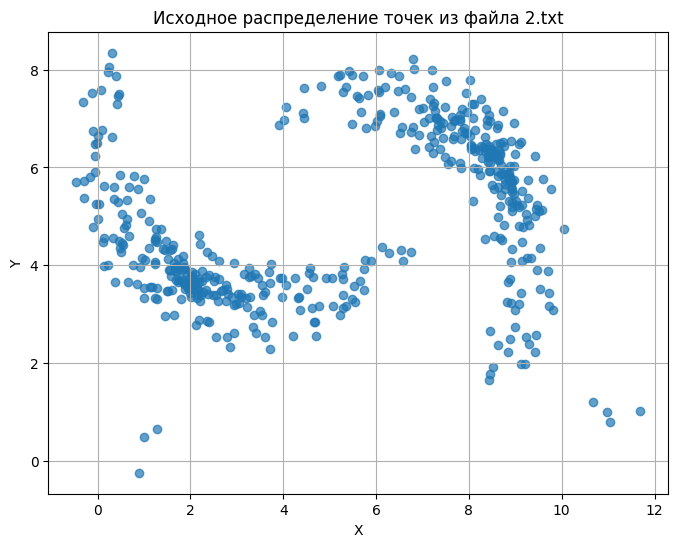

Найдено 2 кластеров
Найдено 7 аномалий
Кластер 1 - Центроидная точка: (8.279901, 6.194730)
Кластер 2 - Центроидная точка: (2.038762, 3.785011)
Среднее абсцисс центроидов * 100000: 515933.153224
Среднее ординат центроидов * 100000: 498987.095483


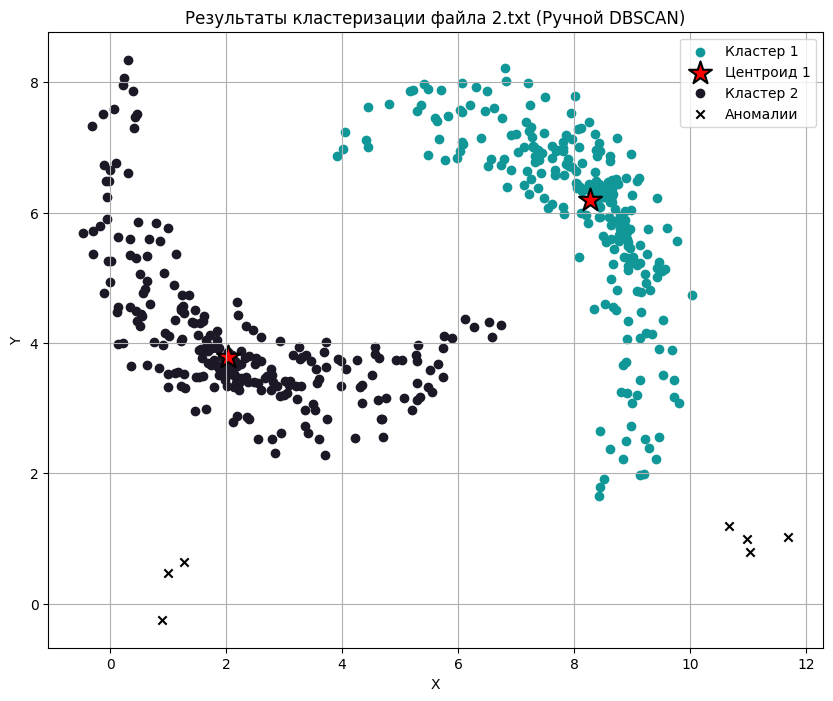

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt
import random

# Загрузка данных из текстового файла 2.txt
with open("2.txt", "r") as f:
    lines = f.readlines()
    # Пропускаем первую строку, так как она содержит заголовок 'X,Y'
    a = []
    for line in lines[1:]:  # Skip the header line
        if line.strip():
            # Разбираем строку, заменяя запятые на пробелы, если нужно
            values = list(map(float, line.replace(',', ' ').split()))
            if len(values) >= 2:  # Проверяем, что есть как минимум x и y координаты
                a.append(values)

print(f"Загружено {len(a)} точек из файла 2.txt")
if a:
    print(f"Первые 5 точек: {a[:5]}")

# Визуализация исходных данных
if a:
    x_coords = [point[0] for point in a]
    y_coords = [point[1] for point in a]
    plt.figure(figsize=(8, 6))
    plt.scatter(x_coords, y_coords, alpha=0.7)
    plt.title('Исходное распределение точек из файла 2.txt')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.show()

# Реализация алгоритма DBSCAN для кластеризации
cl = []  # Список кластеров
anom = []  # Список аномалий
a_copy = a.copy()  # Создаем копию массива, чтобы не изменять исходные данные

# Обрабатываем каждую точку
for i in range(len(a_copy)):
    if a_copy[i] != '*':  # Проверяем, не обработана ли уже точка
        b = []  # Текущий кластер/группа точек
        b.append(a_copy[i])
        a_copy[i] = '*'  # Помечаем точку как обработанную
        
        # Расширяем кластер, добавляя соседние точки
        for l in b:
            x, y = l
            for j in range(len(a_copy)):
                if a_copy[j] != '*':  # Проверяем только необработанные точки
                    # Вычисляем евклидово расстояние между точками
                    if ((x - a_copy[j][0])**2 + (y - a_copy[j][1])**2)**0.5 <= 1:
                        b.append(a_copy[j])
                        a_copy[j] = '*'  # Помечаем точку как обработанную
        
        # Определяем, является ли группа точек кластером или аномалиями
        if len(b) >= 30:  # Порог для определения кластера
            cl.append(b)
        else:
            for k in range(len(b)):
                anom.append(b[k])

print(f"Найдено {len(cl)} кластеров")
print(f"Найдено {len(anom)} аномалий")

# Для каждого кластера найдем точку с минимальным суммарным расстоянием
# до всех остальных точек кластера (центроид)
sm_x = sm_y = 0
centroids = []

for k in range(len(cl)):
    s_x = s_y = 0
    mn = float('inf')  # Используем float('inf') вместо большого числа
    
    for j in cl[k]:
        x, y = j
        d = 0  # Суммарное расстояние до всех точек в кластере
        
        for i in cl[k]:
            d += ((x - i[0])**2 + (y - i[1])**2)**0.5
            
        if d < mn:
            mn = d
            s_x, s_y = x, y
    
    # Добавляем координаты центроида в общую сумму
    sm_x += s_x
    sm_y += s_y
    centroids.append([s_x, s_y])
    print(f"Кластер {k+1} - Центроидная точка: ({s_x:.6f}, {s_y:.6f})")

# Вычисляем и выводим средние значения координат центроидов * 100000
avg_x = sm_x / len(cl) if cl else 0
avg_y = sm_y / len(cl) if cl else 0
print(f"Среднее абсцисс центроидов * 100000: {avg_x * 100000:.6f}")
print(f"Среднее ординат центроидов * 100000: {avg_y * 100000:.6f}")

# Генерируем случайные цвета для кластеров
colors = []
for _ in range(len(cl)):
    color = f'#{random.randint(0, 0xFFFFFF):06x}'
    while color == '#000000':  # Избегаем черного цвета для кластеров
        color = f'#{random.randint(0, 0xFFFFFF):06x}'
    colors.append(color)

# Визуализация результатов кластеризации
plt.figure(figsize=(10, 8))

# Отображаем каждый кластер своим цветом
for i, cluster in enumerate(cl):
    x, y = zip(*cluster)
    plt.scatter(x, y, color=colors[i], label=f'Кластер {i+1}')
    
    # Выделяем центроидную точку для кластера
    plt.scatter(centroids[i][0], centroids[i][1], color='red', marker='*', s=300, 
                edgecolor='black', linewidth=1.5, label=f'Центроид {i+1}' if i == 0 else "")

# Отображаем аномалии черным цветом
if anom:
    x_anom, y_anom = zip(*anom)
    plt.scatter(x_anom, y_anom, color='black', marker='x', label='Аномалии')

plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Результаты кластеризации файла 2.txt (Ручной DBSCAN)')
plt.grid(True)

plt.show()


Загружено 9999 точек из файла 3.txt
Первые 5 точек: [[6.258956881727652, 8.241570813427023], [6.620541378892819, 8.203320373482073], [1.485459356068429, 0.09870276343874007], [1.64258061057667, 0.07579238425573687], [4.163486852124807, 3.5980445993999393]]


Загружено 9999 точек из файла 3.txt
Первые 5 точек: [[6.258956881727652, 8.241570813427023], [6.620541378892819, 8.203320373482073], [1.485459356068429, 0.09870276343874007], [1.64258061057667, 0.07579238425573687], [4.163486852124807, 3.5980445993999393]]


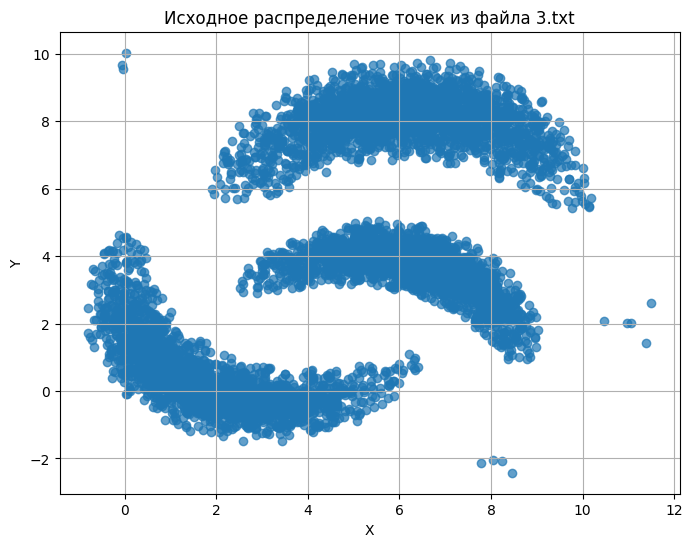

Загружено 9999 точек из файла 3.txt
Первые 5 точек: [[6.258956881727652, 8.241570813427023], [6.620541378892819, 8.203320373482073], [1.485459356068429, 0.09870276343874007], [1.64258061057667, 0.07579238425573687], [4.163486852124807, 3.5980445993999393]]


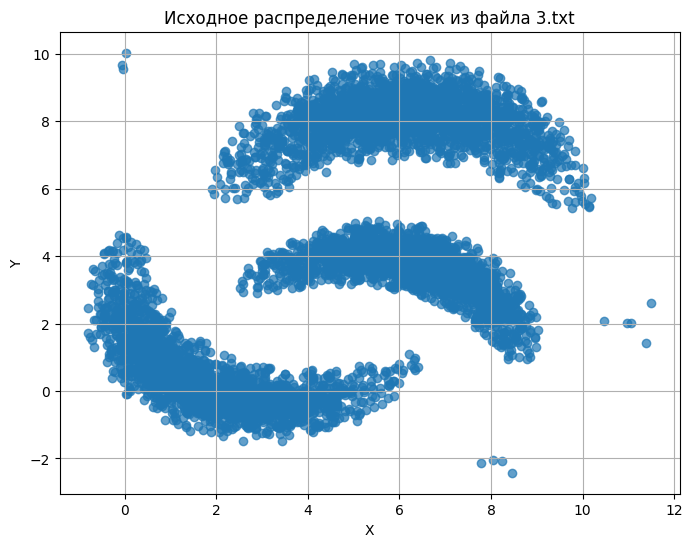

Найдено 3 кластеров
Найдено 12 аномалий
Кластер 1 - Центроидная точка: (6.097276, 8.290450)
Кластер 1 - Центроидная точка: (6.097276, 8.290450)
Кластер 2 - Центроидная точка: (1.696151, 0.129263)
Кластер 2 - Центроидная точка: (1.696151, 0.129263)
Кластер 3 - Центроидная точка: (6.338891, 3.856333)
Среднее абсцисс центроидов * 100000: 471077.274315
Среднее ординат центроидов * 100000: 409201.514710
Кластер 3 - Центроидная точка: (6.338891, 3.856333)
Среднее абсцисс центроидов * 100000: 471077.274315
Среднее ординат центроидов * 100000: 409201.514710


Загружено 9999 точек из файла 3.txt
Первые 5 точек: [[6.258956881727652, 8.241570813427023], [6.620541378892819, 8.203320373482073], [1.485459356068429, 0.09870276343874007], [1.64258061057667, 0.07579238425573687], [4.163486852124807, 3.5980445993999393]]


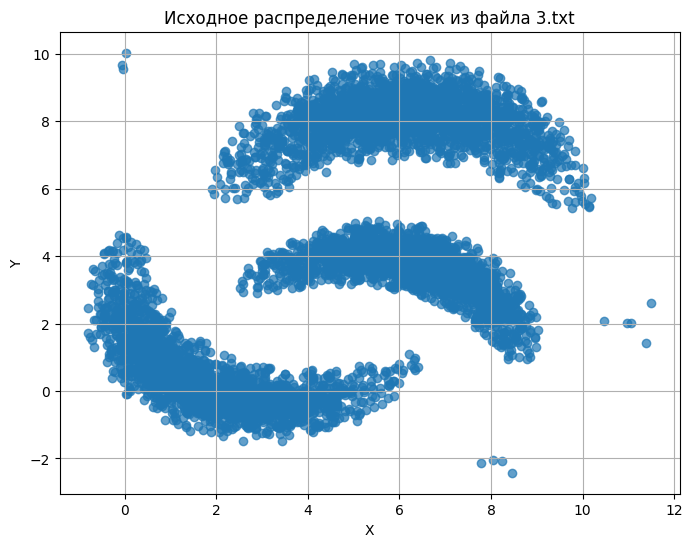

Найдено 3 кластеров
Найдено 12 аномалий
Кластер 1 - Центроидная точка: (6.097276, 8.290450)
Кластер 1 - Центроидная точка: (6.097276, 8.290450)
Кластер 2 - Центроидная точка: (1.696151, 0.129263)
Кластер 2 - Центроидная точка: (1.696151, 0.129263)
Кластер 3 - Центроидная точка: (6.338891, 3.856333)
Среднее абсцисс центроидов * 100000: 471077.274315
Среднее ординат центроидов * 100000: 409201.514710
Кластер 3 - Центроидная точка: (6.338891, 3.856333)
Среднее абсцисс центроидов * 100000: 471077.274315
Среднее ординат центроидов * 100000: 409201.514710


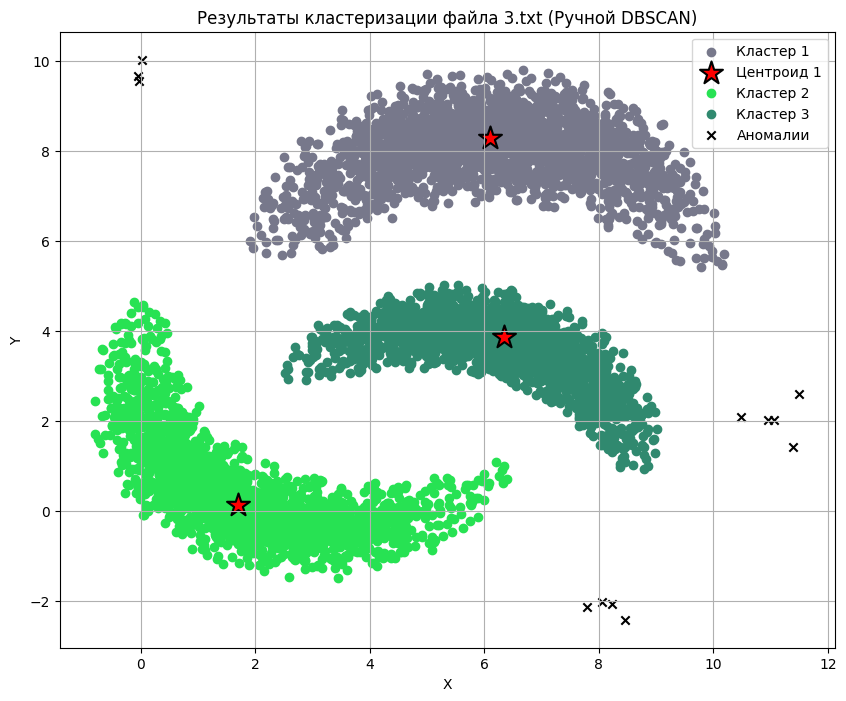

In [ ]:
import matplotlib.pyplot as plt
from math import sqrt
import random
import numpy as np

# Загрузка данных из текстового файла 3.txt
with open("3.txt", "r") as f:
    lines = f.readlines()
    # Пропускаем первую строку, так как она содержит заголовок 'X,Y'
    a = []
    for line in lines[1:]:  # Skip the header line
        if line.strip():
            # Разбираем строку, заменяя запятые на пробелы, если нужно
            values = list(map(float, line.replace(',', ' ').split()))
            if len(values) >= 2:  # Проверяем, что есть как минимум x и y координаты
                a.append(values)

print(f"Загружено {len(a)} точек из файла 3.txt")
if a:
    print(f"Первые 5 точек: {a[:5]}")

# Визуализация исходных данных
if a:
    x_coords = [point[0] for point in a]
    y_coords = [point[1] for point in a]
    plt.figure(figsize=(8, 6))
    plt.scatter(x_coords, y_coords, alpha=0.7)
    plt.title('Исходное распределение точек из файла 3.txt')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.show()

# Реализация алгоритма DBSCAN для кластеризации
cl = []  # Список кластеров
anom = []  # Список аномалий
a_copy = a.copy()  # Создаем копию массива, чтобы не изменять исходные данные

# Обрабатываем каждую точку
for i in range(len(a_copy)):
    if a_copy[i] != '*':  # Проверяем, не обработана ли уже точка
        b = []  # Текущий кластер/группа точек
        b.append(a_copy[i])
        a_copy[i] = '*'  # Помечаем точку как обработанную
        
        # Расширяем кластер, добавляя соседние точки
        for l in b:
            x, y = l
            for j in range(len(a_copy)):
                if a_copy[j] != '*':  # Проверяем только необработанные точки
                    # Вычисляем евклидово расстояние между точками
                    if ((x - a_copy[j][0])**2 + (y - a_copy[j][1])**2)**0.5 <= 1:
                        b.append(a_copy[j])
                        a_copy[j] = '*'  # Помечаем точку как обработанную
        
        # Определяем, является ли группа точек кластером или аномалиями
        if len(b) >= 30:  # Порог для определения кластера
            cl.append(b)
        else:
            for k in range(len(b)):
                anom.append(b[k])

print(f"Найдено {len(cl)} кластеров")
print(f"Найдено {len(anom)} аномалий")

# Для каждого кластера найдем точку с минимальным суммарным расстоянием
# до всех остальных точек кластера (центроид)
sm_x = sm_y = 0
centroids = []

for k in range(len(cl)):
    s_x = s_y = 0
    mn = float('inf')  # Используем float('inf') вместо большого числа
    
    for j in cl[k]:
        x, y = j
        d = 0  # Суммарное расстояние до всех точек в кластере
        
        for i in cl[k]:
            d += ((x - i[0])**2 + (y - i[1])**2)**0.5
            
        if d < mn:
            mn = d
            s_x, s_y = x, y
    
    # Добавляем координаты центроида в общую сумму
    sm_x += s_x
    sm_y += s_y
    centroids.append([s_x, s_y])
    print(f"Кластер {k+1} - Центроидная точка: ({s_x:.6f}, {s_y:.6f})")

# Вычисляем и выводим средние значения координат центроидов * 100000
avg_x = sm_x / len(cl) if cl else 0
avg_y = sm_y / len(cl) if cl else 0
print(f"Среднее абсцисс центроидов * 100000: {avg_x * 100000:.6f}")
print(f"Среднее ординат центроидов * 100000: {avg_y * 100000:.6f}")

# Генерируем случайные цвета для кластеров
colors = []
for _ in range(len(cl)):
    color = f'#{random.randint(0, 0xFFFFFF):06x}'
    while color == '#000000':  # Избегаем черного цвета для кластеров
        color = f'#{random.randint(0, 0xFFFFFF):06x}'
    colors.append(color)

# Визуализация результатов кластеризации
plt.figure(figsize=(10, 8))

# Отображаем каждый кластер своим цветом
for i, cluster in enumerate(cl):
    x, y = zip(*cluster)
    plt.scatter(x, y, color=colors[i], label=f'Кластер {i+1}')
    
    # Выделяем центроидную точку для кластера
    plt.scatter(centroids[i][0], centroids[i][1], color='red', marker='*', s=300, 
                edgecolor='black', linewidth=1.5, label=f'Центроид {i+1}' if i == 0 else "")

# Отображаем аномалии черным цветом
if anom:
    x_anom, y_anom = zip(*anom)
    plt.scatter(x_anom, y_anom, color='black', marker='x', label='Аномалии')

plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Результаты кластеризации файла 3.txt (Ручной DBSCAN)')
plt.grid(True)

plt.show()


Загружено 499 точек из файла 4.txt
Первые 5 точек: [[6.982101824511517, 1.7336083731107097], [4.371828845472861, 3.078402130068878], [6.259451958133373, -0.502482103817333], [6.468899003902035, 0.1313616799768429], [4.306935224723318, 1.288844827646476]]


Загружено 499 точек из файла 4.txt
Первые 5 точек: [[6.982101824511517, 1.7336083731107097], [4.371828845472861, 3.078402130068878], [6.259451958133373, -0.502482103817333], [6.468899003902035, 0.1313616799768429], [4.306935224723318, 1.288844827646476]]


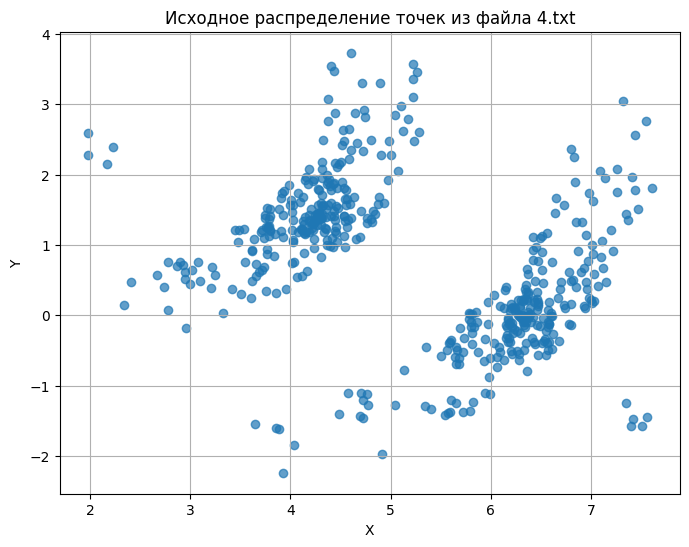

Загружено 499 точек из файла 4.txt
Первые 5 точек: [[6.982101824511517, 1.7336083731107097], [4.371828845472861, 3.078402130068878], [6.259451958133373, -0.502482103817333], [6.468899003902035, 0.1313616799768429], [4.306935224723318, 1.288844827646476]]


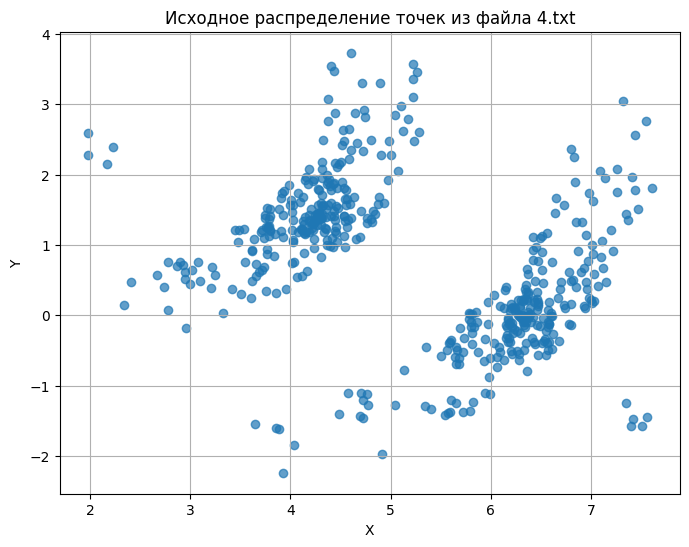

Найдено 2 кластеров
Найдено 9 аномалий
Кластер 1 - Центроидная точка: (6.316702, 0.004171)
Кластер 2 - Центроидная точка: (4.244770, 1.431458)
Среднее абсцисс центроидов * 100000: 528073.608015
Среднее ординат центроидов * 100000: 71781.456057


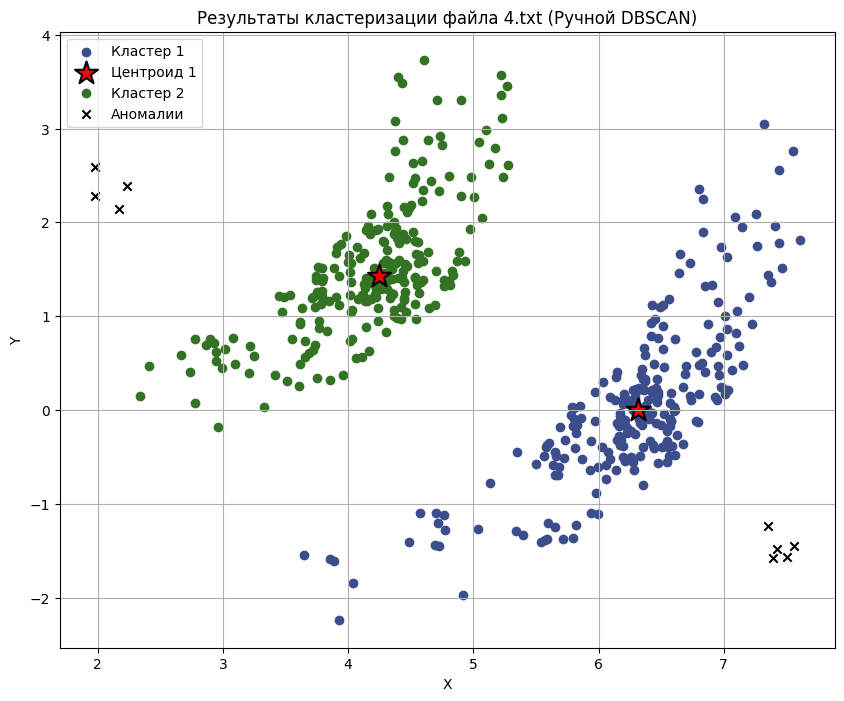

In [4]:
import matplotlib.pyplot as plt
from math import sqrt
import random

# Загрузка данных из текстового файла 4.txt
with open("4.txt", "r") as f:
    lines = f.readlines()
    # Пропускаем первую строку, так как она содержит заголовок 'X,Y'
    a = []
    for line in lines[1:]:  # Skip the header line
        if line.strip():
            # Разбираем строку, заменяя запятые на пробелы, если нужно
            values = list(map(float, line.replace(',', ' ').split()))
            if len(values) >= 2:  # Проверяем, что есть как минимум x и y координаты
                a.append(values)

print(f"Загружено {len(a)} точек из файла 4.txt")
if a:
    print(f"Первые 5 точек: {a[:5]}")

# Визуализация исходных данных
if a:
    x_coords = [point[0] for point in a]
    y_coords = [point[1] for point in a]
    plt.figure(figsize=(8, 6))
    plt.scatter(x_coords, y_coords, alpha=0.7)
    plt.title('Исходное распределение точек из файла 4.txt')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.show()

# Реализация алгоритма DBSCAN для кластеризации
cl = []  # Список кластеров
anom = []  # Список аномалий
a_copy = a.copy()  # Создаем копию массива, чтобы не изменять исходные данные

# Обрабатываем каждую точку
for i in range(len(a_copy)):
    if a_copy[i] != '*':  # Проверяем, не обработана ли уже точка
        b = []  # Текущий кластер/группа точек
        b.append(a_copy[i])
        a_copy[i] = '*'  # Помечаем точку как обработанную
        
        # Расширяем кластер, добавляя соседние точки
        for l in b:
            x, y = l
            for j in range(len(a_copy)):
                if a_copy[j] != '*':  # Проверяем только необработанные точки
                    # Вычисляем евклидово расстояние между точками
                    if ((x - a_copy[j][0])**2 + (y - a_copy[j][1])**2)**0.5 <= 1:
                        b.append(a_copy[j])
                        a_copy[j] = '*'  # Помечаем точку как обработанную
        
        # Определяем, является ли группа точек кластером или аномалиями
        if len(b) >= 30:  # Порог для определения кластера
            cl.append(b)
        else:
            for k in range(len(b)):
                anom.append(b[k])

print(f"Найдено {len(cl)} кластеров")
print(f"Найдено {len(anom)} аномалий")

# Для каждого кластера найдем точку с минимальным суммарным расстоянием
# до всех остальных точек кластера (центроид)
sm_x = sm_y = 0
centroids = []

for k in range(len(cl)):
    s_x = s_y = 0
    mn = float('inf')  # Используем float('inf') вместо большого числа
    
    for j in cl[k]:
        x, y = j
        d = 0  # Суммарное расстояние до всех точек в кластере
        
        for i in cl[k]:
            d += ((x - i[0])**2 + (y - i[1])**2)**0.5
            
        if d < mn:
            mn = d
            s_x, s_y = x, y
    
    # Добавляем координаты центроида в общую сумму
    sm_x += s_x
    sm_y += s_y
    centroids.append([s_x, s_y])
    print(f"Кластер {k+1} - Центроидная точка: ({s_x:.6f}, {s_y:.6f})")

# Вычисляем и выводим средние значения координат центроидов * 100000
avg_x = sm_x / len(cl) if cl else 0
avg_y = sm_y / len(cl) if cl else 0
print(f"Среднее абсцисс центроидов * 100000: {avg_x * 100000:.6f}")
print(f"Среднее ординат центроидов * 100000: {avg_y * 100000:.6f}")

# Генерируем случайные цвета для кластеров
colors = []
for _ in range(len(cl)):
    color = f'#{random.randint(0, 0xFFFFFF):06x}'
    while color == '#000000':  # Избегаем черного цвета для кластеров
        color = f'#{random.randint(0, 0xFFFFFF):06x}'
    colors.append(color)

# Визуализация результатов кластеризации
plt.figure(figsize=(10, 8))

# Отображаем каждый кластер своим цветом
for i, cluster in enumerate(cl):
    x, y = zip(*cluster)
    plt.scatter(x, y, color=colors[i], label=f'Кластер {i+1}')
    
    # Выделяем центроидную точку для кластера
    plt.scatter(centroids[i][0], centroids[i][1], color='red', marker='*', s=300, 
                edgecolor='black', linewidth=1.5, label=f'Центроид {i+1}' if i == 0 else "")

# Отображаем аномалии черным цветом
if anom:
    x_anom, y_anom = zip(*anom)
    plt.scatter(x_anom, y_anom, color='black', marker='x', label='Аномалии')

plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Результаты кластеризации файла 4.txt (Ручной DBSCAN)')
plt.grid(True)

plt.show()


Загружено 9998 точек из файла 5.txt
Первые 5 точек: [[4.216153613532527, 0.7409192983570715], [5.844846169918614, 2.854216706876828], [9.906416257280558, 6.189253125224514], [5.670448250890671, 4.76953895130312], [9.819829777158514, 5.135322522506984]]


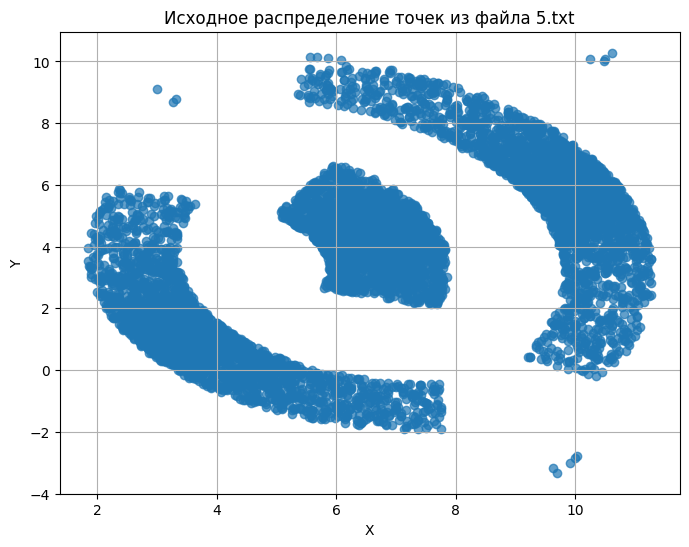

Найдено 3 кластеров
Найдено 12 аномалий
Кластер 1 - Центроидная точка: (3.583692, 0.999784)
Кластер 2 - Центроидная точка: (6.632439, 4.292176)
Кластер 3 - Центроидная точка: (9.882268, 5.829084)
Среднее абсцисс центроидов * 100000: 669946.649007
Среднее ординат центроидов * 100000: 370701.476542


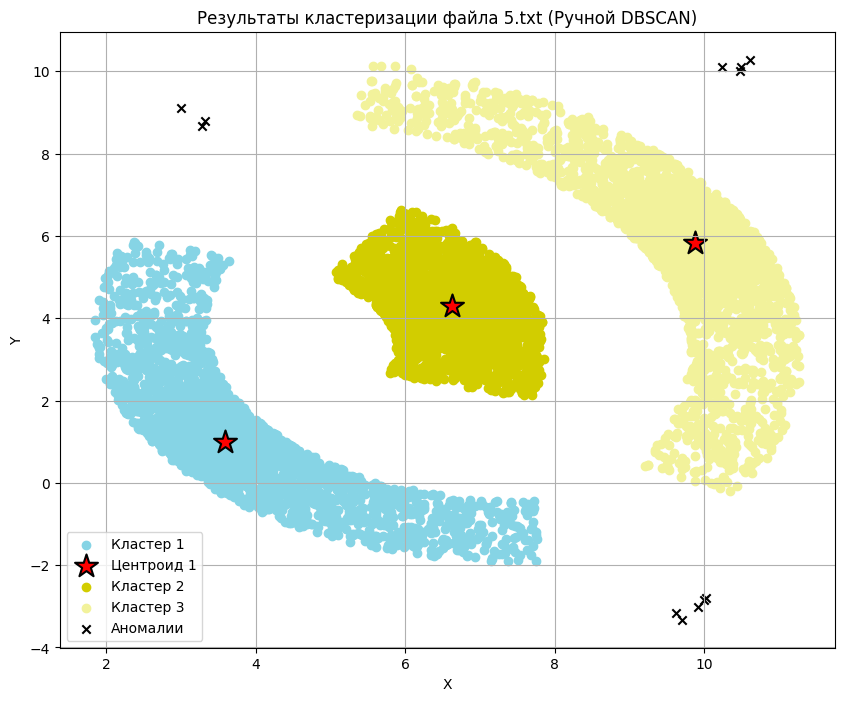

In [ ]:
import matplotlib.pyplot as plt
from math import sqrt
import random
import numpy as np

# Загрузка данных из текстового файла 5.txt
with open("5.txt", "r") as f:
    lines = f.readlines()
    # Пропускаем первую строку, так как она содержит заголовок 'X,Y'
    a = []
    for line in lines[1:]:  # Skip the header line
        if line.strip():
            # Разбираем строку, заменяя запятые на пробелы, если нужно
            values = list(map(float, line.replace(',', ' ').split()))
            if len(values) >= 2:  # Проверяем, что есть как минимум x и y координаты
                a.append(values)

print(f"Загружено {len(a)} точек из файла 5.txt")
if a:
    print(f"Первые 5 точек: {a[:5]}")

# Визуализация исходных данных
if a:
    x_coords = [point[0] for point in a]
    y_coords = [point[1] for point in a]
    plt.figure(figsize=(8, 6))
    plt.scatter(x_coords, y_coords, alpha=0.7)
    plt.title('Исходное распределение точек из файла 5.txt')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.show()

# Реализация алгоритма DBSCAN для кластеризации
cl = []  # Список кластеров
anom = []  # Список аномалий
a_copy = a.copy()  # Создаем копию массива, чтобы не изменять исходные данные

# Обрабатываем каждую точку
for i in range(len(a_copy)):
    if a_copy[i] != '*':  # Проверяем, не обработана ли уже точка
        b = []  # Текущий кластер/группа точек
        b.append(a_copy[i])
        a_copy[i] = '*'  # Помечаем точку как обработанную
        
        # Расширяем кластер, добавляя соседние точки
        idx = 0
        while idx < len(b):  # Используем while, чтобы обрабатывать новые добавленные точки
            x, y = b[idx]
            for j in range(len(a_copy)):
                if a_copy[j] != '*':  # Проверяем только необработанные точки
                    # Вычисляем евклидово расстояние между точками
                    if ((x - a_copy[j][0])**2 + (y - a_copy[j][1])**2)**0.5 <= 1:
                        b.append(a_copy[j])
                        a_copy[j] = '*'  # Помечаем точку как обработанную
            idx += 1
        
        # Определяем, является ли группа точек кластером или аномалиями
        if len(b) >= 30:  # Порог для определения кластера
            cl.append(b)
        else:
            for k in range(len(b)):
                anom.append(b[k])

print(f"Найдено {len(cl)} кластеров")
print(f"Найдено {len(anom)} аномалий")

# Для каждого кластера найдем точку с минимальным суммарным расстоянием
# до всех остальных точек кластера (центроид)
sm_x = sm_y = 0
centroids = []

for k in range(len(cl)):
    s_x = s_y = 0
    mn = float('inf')  # Используем float('inf') вместо большого числа
    
    for j in cl[k]:
        x, y = j
        d = 0  # Суммарное расстояние до всех точек в кластере
        
        for i in cl[k]:
            d += ((x - i[0])**2 + (y - i[1])**2)**0.5
            
        if d < mn:
            mn = d
            s_x, s_y = x, y
    
    # Добавляем координаты центроида в общую сумму
    sm_x += s_x
    sm_y += s_y
    centroids.append([s_x, s_y])
    print(f"Кластер {k+1} - Центроидная точка: ({s_x:.6f}, {s_y:.6f})")

# Вычисляем и выводим средние значения координат центроидов * 100000
avg_x = sm_x / len(cl) if cl else 0
avg_y = sm_y / len(cl) if cl else 0
print(f"Среднее абсцисс центроидов * 100000: {avg_x * 100000:.6f}")
print(f"Среднее ординат центроидов * 100000: {avg_y * 100000:.6f}")

# Генерируем случайные цвета для кластеров
colors = []
for _ in range(len(cl)):
    color = f'#{random.randint(0, 0xFFFFFF):06x}'
    while color == '#000000':  # Избегаем черного цвета для кластеров
        color = f'#{random.randint(0, 0xFFFFFF):06x}'
    colors.append(color)

# Визуализация результатов кластеризации
plt.figure(figsize=(10, 8))

# Отображаем каждый кластер своим цветом
for i, cluster in enumerate(cl):
    x, y = zip(*cluster)
    plt.scatter(x, y, color=colors[i], label=f'Кластер {i+1}')
    
    # Выделяем центроидную точку для кластера
    plt.scatter(centroids[i][0], centroids[i][1], color='red', marker='*', s=300, 
                edgecolor='black', linewidth=1.5, label=f'Центроид {i+1}' if i == 0 else "")

# Отображаем аномалии черным цветом
if anom:
    x_anom, y_anom = zip(*anom)
    plt.scatter(x_anom, y_anom, color='black', marker='x', label='Аномалии')

plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Результаты кластеризации файла 5.txt (Ручной DBSCAN)')
plt.grid(True)

plt.show()


# Кластеризация (1 за каждый алгоритм на всех данных)

На предложенных распределениях данных проверьте предложенные алгоритмы. Постройте графики кластеризации для каждой пары алгоритм-данные, разные кластеры покрасьте разным цветом. Воспользуйтесь sklearn реализациями. Параметры кластеризации для разных алгоритмов подберите такие, чтобы алгоритмы можно было сравнивать (по возможности одинаковое количество кластеров и т.д.)

In [5]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, MeanShift, SpectralClustering, AgglomerativeClustering, OPTICS
from sklearn.mixture import GaussianMixture
from itertools import cycle, islice

In [9]:
two_means = cluster.KMeans(n_clusters=3)
dbscan = cluster.DBSCAN(eps=0.3)

# Определяем параметры для сравнимости (где возможно, n_clusters=3)
default_params = {"n_clusters": 3, "n_components": 3}

# Определяем 7 алгоритмов кластеризации для сравнения
clustering_algorithms = (
    ("KMeans", KMeans(n_clusters=default_params["n_clusters"])),
    ("MeanShift", MeanShift()), # Количество кластеров определяется автоматически
    ("Spectral\nClustering", SpectralClustering(n_clusters=default_params["n_clusters"])),
    ("Ward", AgglomerativeClustering(n_clusters=default_params["n_clusters"])), # Ward linkage по умолчанию
    ("Agglomerative\nClustering", AgglomerativeClustering(n_clusters=default_params["n_clusters"], linkage='average')), # Используем average linkage для разнообразия
    ("OPTICS", OPTICS(min_samples=20)), # min_samples можно подбирать
    ("Gaussian\nMixture", GaussianMixture(n_components=default_params["n_components"])),
)

--- Dataset: noisy_circles ---
Algorithm: KMeans
  Number of clusters found: 3
  Time taken: 0.01s
Algorithm: MeanShift
  Number of clusters found: 3
  Time taken: 3.55s
Algorithm: Spectral Clustering
  Number of clusters found: 3
  Time taken: 0.18s
Algorithm: MeanShift
  Number of clusters found: 3
  Time taken: 3.55s
Algorithm: Spectral Clustering
  Number of clusters found: 3
  Time taken: 0.18s
Algorithm: Ward
  Number of clusters found: 3
  Time taken: 0.03s
Algorithm: Agglomerative Clustering
  Number of clusters found: 3
  Time taken: 0.02s
Algorithm: Ward
  Number of clusters found: 3
  Time taken: 0.03s
Algorithm: Agglomerative Clustering
  Number of clusters found: 3
  Time taken: 0.02s
Algorithm: OPTICS
  Number of clusters found: 16
  Number of noise points: 924
  Time taken: 0.54s
Algorithm: Gaussian Mixture
  Number of clusters found: 3
  Time taken: 0.01s
------------------------------
--- Dataset: noisy_moons ---
Algorithm: KMeans
  Number of clusters found: 3
  Time t

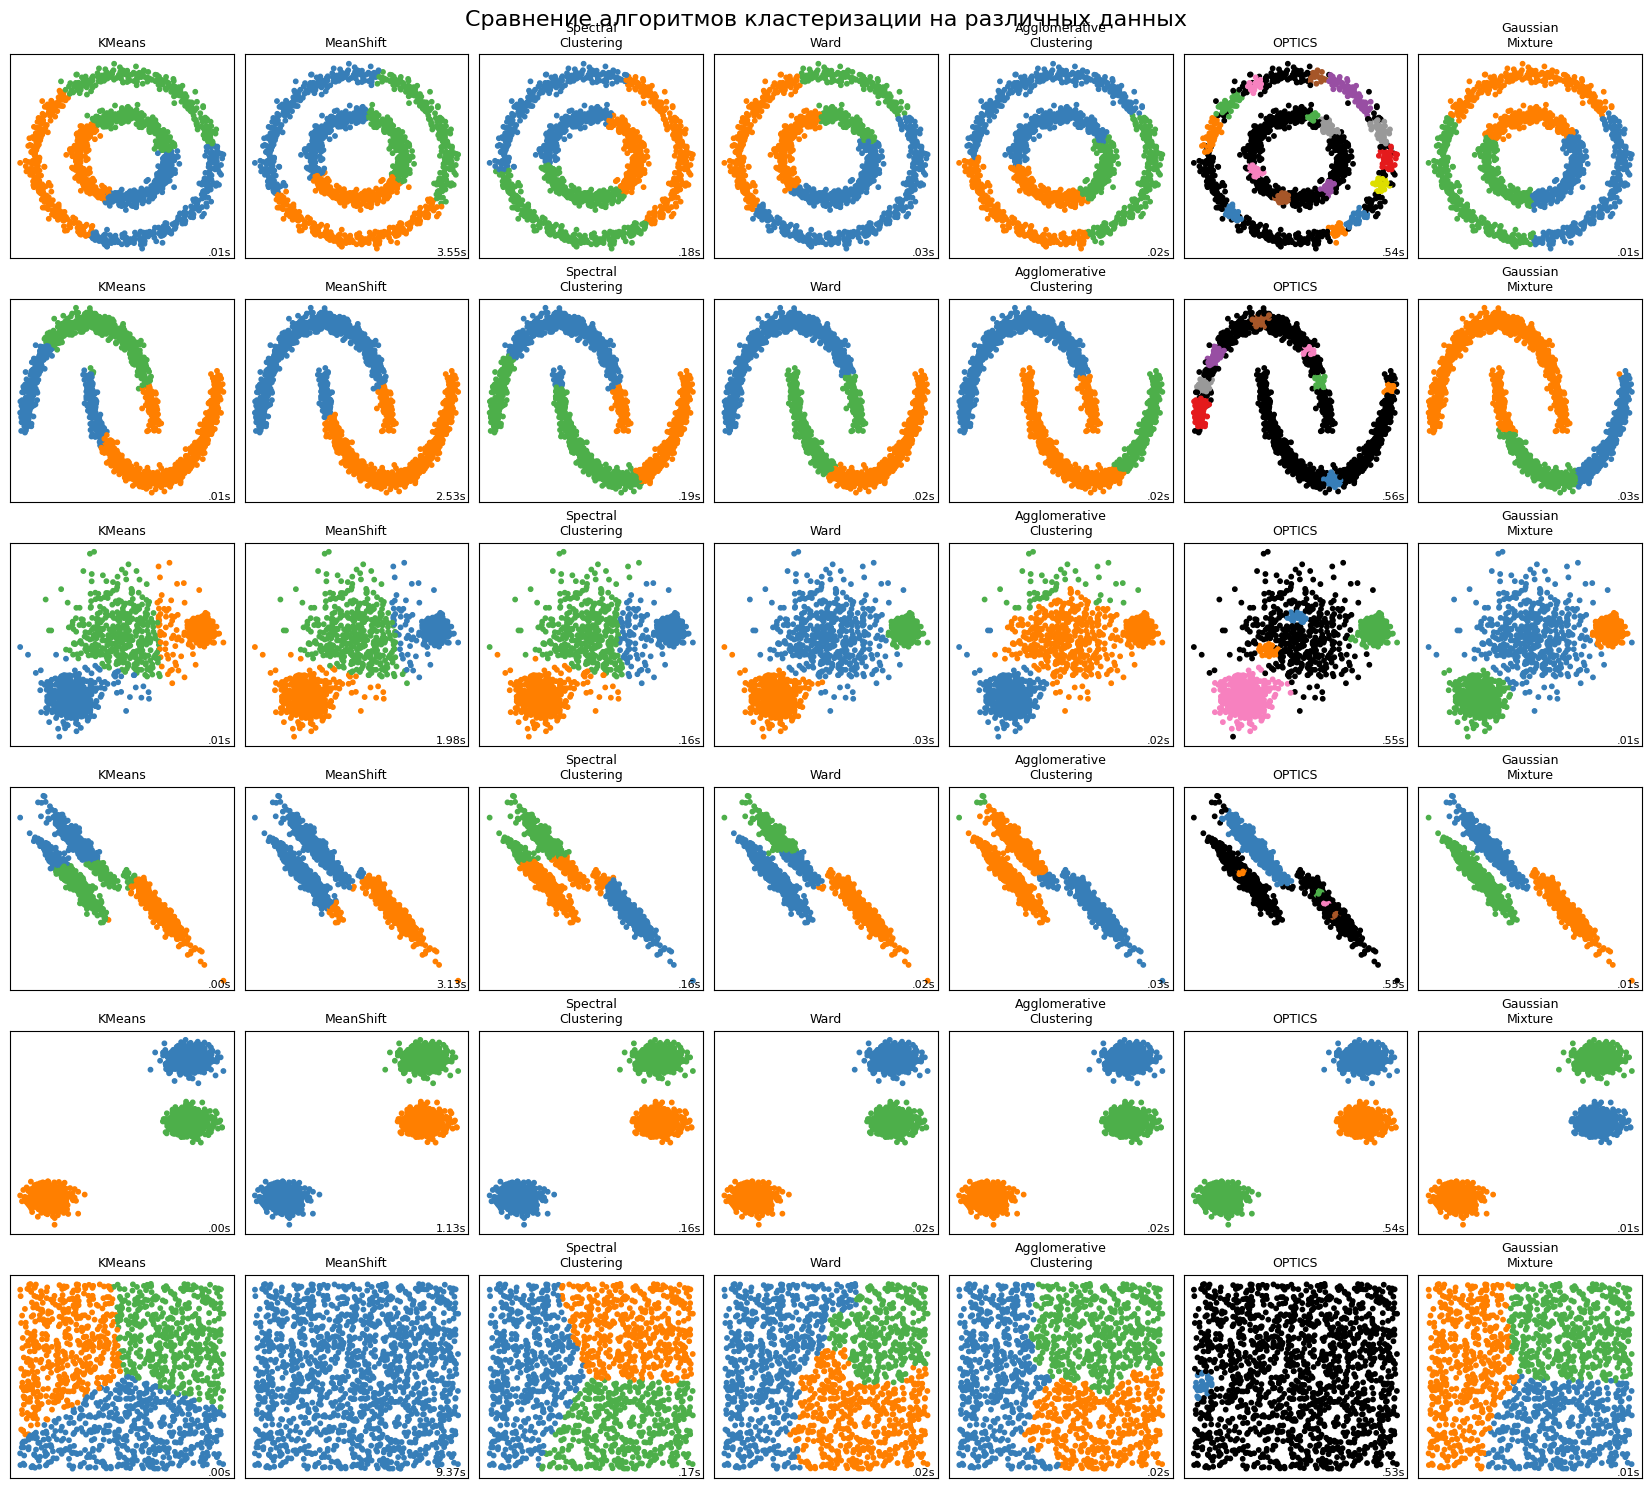

In [12]:
warnings.filterwarnings("ignore")
n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
no_structure = (np.random.rand(n_samples, 2), None)

random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)

# Добавим словарь для хранения результатов по каждому алгоритму
clustering_results = {}

# Add dataset names for printing results
dataset_names = ["noisy_circles", "noisy_moons", "varied", "aniso", "blobs", "no_structure"]
datasets_list = [
    noisy_circles,
    noisy_moons,
    varied,
    aniso,
    blobs,
    no_structure,
]

plt.figure(figsize=(len(clustering_algorithms) * 2 + 3, 15))
plt.subplots_adjust(left=0.02, right=0.98, bottom=0.001, top=0.95, wspace=0.05, hspace=0.2)
plot_num = 1

for i_dataset, dataset in enumerate(datasets_list):
    X, y = dataset
    X = StandardScaler().fit_transform(X)
    
    # Print dataset name before processing algorithms
    print(f"--- Dataset: {dataset_names[i_dataset]} ---")

    # Инициализируем словарь для текущего набора данных
    if dataset_names[i_dataset] not in clustering_results:
        clustering_results[dataset_names[i_dataset]] = {}

    for name, algorithm in clustering_algorithms:
        t0 = time.time()

        if name == "Gaussian\nMixture":
            algorithm.fit(X)
            y_pred = algorithm.predict(X)
        else:
            y_pred = algorithm.fit_predict(X)

        t1 = time.time()
        
        # --- Print results for each algorithm --- 
        n_clusters_ = len(set(y_pred)) - (1 if -1 in y_pred else 0) # Calculate number of clusters found
        n_noise_ = list(y_pred).count(-1) # Calculate number of noise points (if algorithm assigns -1)
        
        print(f"Algorithm: {name.replace('\n', ' ')}")
        print(f"  Number of clusters found: {n_clusters_}")
        if n_noise_ > 0:
            print(f"  Number of noise points: {n_noise_}")
        print(f"  Time taken: {t1 - t0:.2f}s")
        # --- End of printing results --- 

        # Сохраняем результаты в словарь
        algorithm_name = name.replace('\n', ' ')
        clustering_results[dataset_names[i_dataset]][algorithm_name] = {
            'n_clusters': n_clusters_,
            'n_noise': n_noise_,
            'time': t1 - t0
        }

        plt.subplot(len(datasets_list), len(clustering_algorithms), plot_num)
        if hasattr(algorithm, "labels_"):
            y_pred = algorithm.labels_

        colors = np.array(list(islice(cycle(["#377eb8", "#ff7f00", "#4daf4a",
                                             "#f781bf", "#a65628", "#984ea3",
                                             "#999999", "#e41a1c", "#dede00"]),
                                      int(max(y_pred) + 1))))
        colors = np.append(colors, ["#000000"])

        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[y_pred])
        plt.title(name, size=9)
        plt.xticks([])
        plt.yticks([])
        plt.text(.99, .01, ('%.2fs' % (t1 - t0)).lstrip('0'),
                 transform=plt.gca().transAxes, size=8,
                 horizontalalignment='right')
        plot_num += 1
    
    # Add separator after processing all algorithms for a dataset
    print("-" * 30)

plt.suptitle("Сравнение алгоритмов кластеризации на различных данных", fontsize=16)
plt.show()


## Анализ работы алгоритмов кластеризации

При сравнении различных алгоритмов кластеризации на разных типах данных можно сделать следующие наблюдения:

**KMeans**: Быстрый и эффективный алгоритм, который прекрасно работает с данными, где кластеры имеют сферическую форму и примерно одинаковый размер (как в наборе `blobs`). Однако заметно хуже справляется с данными сложной формы, такими как полумесяцы (`noisy_moons`) или окружности (`noisy_circles`). Главное преимущество - высокая скорость работы даже на больших наборах данных.

**MeanShift**: Автоматически определяет количество кластеров на основе плотности данных. Это избавляет от необходимости заранее задавать число кластеров, но может привести к неожиданным результатам при небольших изменениях данных. Лучше справляется с нелинейными формами кластеров, чем KMeans.

**Spectral Clustering**: Демонстрирует отличные результаты на данных со сложной геометрией кластеров, таких как круги и полумесяцы. Это происходит благодаря использованию собственных векторов матрицы сходства, что позволяет находить нелинейные структуры. Основной недостаток - вычислительная сложность при работе с большими наборами данных. Бяка. 

**Ward** и **Agglomerative Clustering**: Оба алгоритма используют иерархический подход, постепенно объединяя точки в кластеры. Ward стремится минимизировать дисперсию внутри кластеров, что приводит к более компактным и равномерным группам. Agglomerative с linkage='average' более гибкий в отношении формы кластеров. Помогают посмотреть на данные с разных уровней датализации 

**OPTICS**: Подобно DBSCAN, этот алгоритм основан на плотности и может обнаруживать кластеры произвольной формы. Он хорошо справляется с шумом и выбросами, отмечая их как -1. Важное преимущество - не требуется заранее указывать количество кластеров, однако настройка параметра `min_samples` может требовать экспериментов. Все же это своебразное улучшение DBSCAN, который вообще мне не понравился из предыдущего дз. Хотя судя по картинкам не сильно лучше dbscan. 

**Gaussian Mixture**: Вероятностный подход, который моделирует данные как смесь нескольких нормальных распределений. Отлично работает с эллиптическими кластерами и данными, имеющими вытянутую форму (например, `aniso`). Возвращает не только метки кластеров, но и вероятности принадлежности к каждому кластеру, что может быть полезно при неоднозначных случаях.

**Общие выводы:**
- Выбор алгоритма существенно зависит от характера данных и поставленной задачи
- Для данных со сложной геометрией следует использовать Spectral Clustering или OPTICS
- При недостатке времени или больших объемах данных KMeans может быть единственным практичным вариантом
- Если количество кластеров неизвестно, полезно сначала применить MeanShift или OPTICS
- Время выполнения алгоритмов сильно различается - от очень быстрого KMeans до ресурсоемкого Spectral Clustering